In [88]:
%pip install qiskit-ibm-runtime qiskit-aer
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import Sampler
from qiskit.visualization import plot_histogram
import numpy as np

Note: you may need to restart the kernel to use updated packages.


Introduction and Definition

Deutsch's Algorithm is a famous quantum algorithm utilized for finding the global property of f(x), namely: f(0) ⊕ F(1) or if the function is 'constant' or 'balanced'.
It leverges both quantum parallelism (evaluating f(x) for different x's simultaneously) and interference (both outcome alternatives interfere with one another)
to achieve this in one execution. This single inqury information is impossible to replicate by classical means, as different outcomes exist independently of 
each another. Deutsch's Algorithm is a early, clean example of quantum advantage and is continually used and expanded upon today.

Implementing Deutsch’s Algorithm

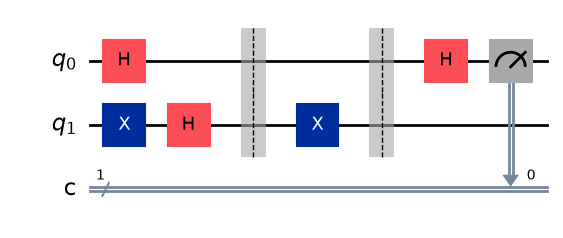

In [198]:
# Creates a two qubit circuit.
qc = QuantumCircuit(2,1)

# Induces superposition in both qubits
qc.x(1)
qc.h(range(0, 2))
qc.barrier()

# Randomly chooses from one of the four main functions (f1, f2, f3, f4) to apply to the circuit
random = np.random.randint(0, 4)
if random == 1 or random == 2:
    qc.cx(0,1)
if random == 2 or random == 3:
    qc.x(1)
qc.barrier()

# Applies Hadamard gate to qubit 0 and displays circuit
qc.h(0)
qc.measure(0, 0)
qc.draw(output='mpl')

Deutsch’s algorithm visualized

In [200]:
# Note: this demo utilizes AerSimulator and does not run on native hardware. Feel free to change to a real backend if wanted.

# Creates a backend from AerSimulator
backend = AerSimulator()

# Creates a pass manager and transpiles our circuit
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_qc = pm.run(qc)

# Runs our transpiled circuit and collects the result
sampler = Sampler(mode=backend)
job = sampler.run([isa_qc], shots=1024)
result = job.result()


# Recieves counts and displays the results. If the measured result is 0: the function is constant. Else: the function is balanced.
counts = result[0].data.c.get_counts()
bit = max(counts, key=counts.get)

if bit == 0:
        print("constant")
else:
      print("balanced") 

balanced


Sources: 
Nielsen, M.A. and Chuang, I.L. (2011) Quantum Computation and Quantum Information: 10th Anniversary Edition. 10th Edition, Cambridge University Press, New York.